In [32]:
import numpy as np
from scipy.stats import norm
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import pandas as pd

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.set_default_device(DEVICE)

In [33]:
def black_scholes_call(S, t, K_, T_, sigma_):
    # Ensure all inputs are PyTorch tensors
    if not isinstance(S, torch.Tensor):
        S = torch.tensor(S, dtype=torch.float32)
    if not isinstance(t, torch.Tensor):
        t = torch.tensor(t, dtype=torch.float32)
    if not isinstance(K_, torch.Tensor):
        K_ = torch.tensor(K_, dtype=torch.float32)
    if not isinstance(T_, torch.Tensor):
        T_ = torch.tensor(T_, dtype=torch.float32)
    if not isinstance(sigma_, torch.Tensor):
        sigma_ = torch.tensor(sigma_, dtype=torch.float32)

    # Time to maturity
    tau = T_ - t

    # Handle cases where tau <= 0 (at or past maturity)
    intrinsic_value = torch.maximum(S - K_, torch.tensor(0.0))
    if tau <= 0:
        return intrinsic_value

    # Compute d1 and d2
    d1 = (torch.log(S / K_) + 0.5 * sigma_**2 * tau) / (sigma_ * torch.sqrt(tau))
    d2 = d1 - sigma_ * torch.sqrt(tau)

    # Normal CDF approximation using torch.erf
    norm_cdf = lambda value: 0.5 * (1 + torch.erf(value / torch.sqrt(torch.tensor(2.0))))

    # Calculate the option price
    call_price = S * norm_cdf(d1) - K_ * norm_cdf(d2)
    return call_price

In [34]:
def black_scholes_analytical(concat_tensor, K_, T_, sigma_):
    # Split the concatenated tensor
    S, t = concat_tensor[:, 0], concat_tensor[:, 1]
    tau = T_ - t
    intrinsic_value = torch.maximum(S - K_, torch.tensor(0.0))
    valid_tau = tau > 0  # Boolean mask for valid tau values
    d1 = (torch.log(S / K_) + 0.5 * sigma_**2 * tau) / (sigma_ * torch.sqrt(tau + 1e-8))  # Add small value for numerical stability
    d2 = d1 - sigma_ * torch.sqrt(tau + 1e-8)
    norm_cdf = lambda value: 0.5 * (1 + torch.erf(value / torch.sqrt(torch.tensor(2.0))))

    # Compute option price only where tau > 0
    V = torch.zeros_like(S)
    V[valid_tau] = S[valid_tau] * norm_cdf(d1[valid_tau]) - K_ * norm_cdf(d2[valid_tau])
    return torch.where(valid_tau, V, intrinsic_value)

C:\Users\jazzo\AppData\Local\Temp\ipykernel_42492\988537444.py:7: RuntimeWarning: divide by zero encountered in log
  d1 = (np.log(S / K) + (sigma**2 / 2) * (T - t)) / (sigma * sqrt_T_t)


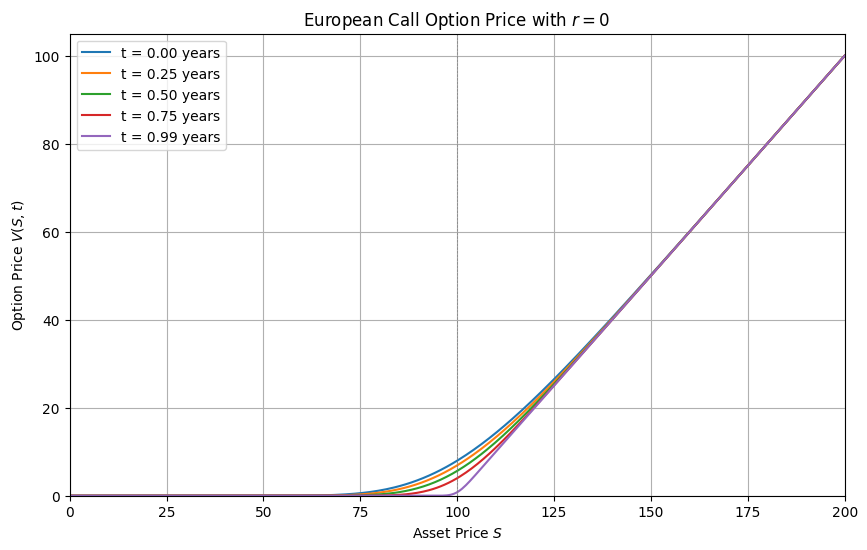

C:\Users\jazzo\AppData\Local\Temp\ipykernel_42492\988537444.py:21: RuntimeWarning: divide by zero encountered in log
  d1 = (np.log(S / K) + (sigma**2 / 2) * (T - t[mask])) / (sigma * sqrt_T_t)


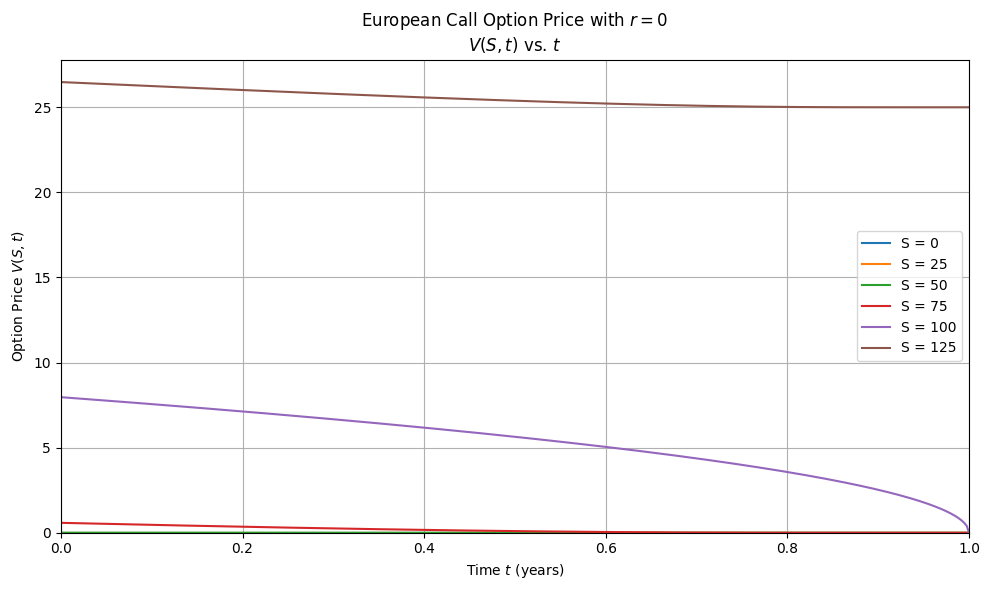

In [35]:
def black_scholes_call_r0(S, t, K, sigma, T):
    if t >= T:
        # At maturity, option value is max(S - K, 0)
        return np.maximum(S - K, 0)
    else:
        sqrt_T_t = np.sqrt(T - t)
        d1 = (np.log(S / K) + (sigma**2 / 2) * (T - t)) / (sigma * sqrt_T_t)
        d2 = d1 - sigma * sqrt_T_t
        V = S * norm.cdf(d1) - K * norm.cdf(d2)
        return V
    

def black_scholes_call_r0_time(S_fixed, t, K, sigma, T):
    V = np.zeros((len(S_fixed), len(t)))
    for i, S in enumerate(S_fixed):
        if S >= K:
            V[i, t >= T] = S - K
        # Compute V for t < T
        mask = t < T
        sqrt_T_t = np.sqrt(T - t[mask])
        d1 = (np.log(S / K) + (sigma**2 / 2) * (T - t[mask])) / (sigma * sqrt_T_t)
        d2 = d1 - sigma * sqrt_T_t
        V[i, mask] = S * norm.cdf(d1) - K * norm.cdf(d2)
    return V


# Parameters
K = 100          # Strike price
sigma = 0.2      # Volatility (20%)
T = 1.0          # Time to maturity in years

# Asset price range
S_min = 0
S_max = 200
num_S = 400
S_values = np.linspace(S_min, S_max, num_S)

# Time points to plot
time_points = [0.0, 0.25, 0.5, 0.75, 0.99]  # in years

plt.figure(figsize=(10, 6))

for t in time_points:
    V = black_scholes_call_r0(S_values, t, K, sigma, T)
    plt.plot(S_values, V, label=f't = {t:.2f} years')

plt.title('European Call Option Price with $r = 0$')
plt.xlabel('Asset Price $S$')
plt.ylabel('Option Price $V(S, t)$')
plt.legend()
plt.grid(True)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(K, color='gray', linestyle='--', linewidth=0.5, label='Strike Price $K$')
plt.xlim(S_min, S_max)
plt.ylim(bottom=0)
plt.show()

# Fixed asset prices for V vs t plot
S_fixed_list = [0, 25, 50, 75, 100, 125]  # Example fixed asset prices

# Time range for V vs t plot
num_t = 400
t_values = np.linspace(0, T, num_t)

# Compute option prices for fixed S over time
V_fixed_S = black_scholes_call_r0_time(S_fixed_list, t_values, K, sigma, T)

# Plot V vs t for various fixed S
plt.figure(figsize=(10, 6))

for i, S in enumerate(S_fixed_list):
    plt.plot(t_values, V_fixed_S[i], label=f'S = {S}')

plt.title('European Call Option Price with $r = 0$\n$V(S, t)$ vs. $t$')
plt.xlabel('Time $t$ (years)')
plt.ylabel('Option Price $V(S, t)$')
plt.legend()
plt.grid(True)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(T, color='gray', linestyle='--', linewidth=0.5, label='Maturity $T$')
plt.xlim(0, T)
plt.ylim(bottom=0)

plt.tight_layout()
plt.show()

In [36]:
K = 50   # Strike price
T = 1   # Maturity time
Smax = 100

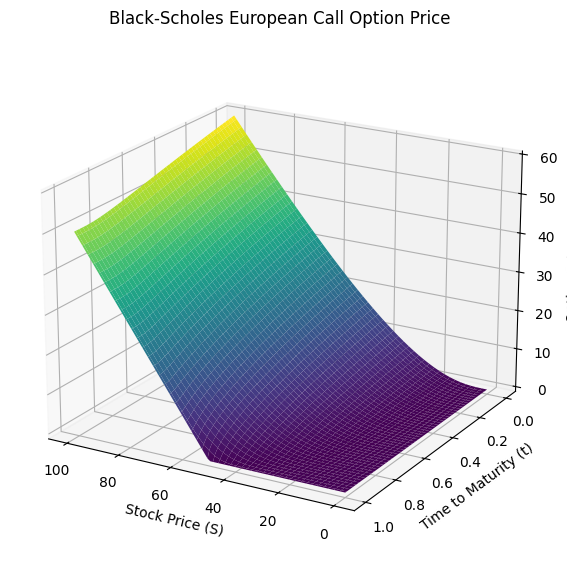

In [37]:
# Create a meshgrid for S (stock price) and t (time)
S = torch.linspace(0, Smax, 100) 
t = torch.linspace(0, T, 100)     # Time from 0 to T
S_grid, t_grid = torch.meshgrid(S, t)

# Compute the option price for each (S, t) pair
call_prices = np.array([black_scholes_call(S_i, t_i, K, T, 1) for S_i, t_i in zip(S_grid.ravel(), t_grid.ravel())])
call_prices = call_prices.reshape(S_grid.shape)

# Plot the 3D surface
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(S_grid, t_grid, call_prices, cmap='viridis', edgecolor='none')
ax.set_title('Black-Scholes European Call Option Price')
ax.set_xlabel('Stock Price (S)')
ax.set_ylabel('Time to Maturity (t)')
ax.set_zlabel('Option Price (V)')
ax.view_init(elev=20, azim=120)
plt.show()

In [38]:
class FCN(nn.Module):
    "Defines a connected network"
    def __init__(self, N_INPUT, N_OUTPUT, N_HIDDEN, N_LAYERS, init_type='he_normal'):
        super().__init__()
        activation = nn.SiLU()
        #activation = nn.CELU()
        #activation = nn.LeakyReLU(negative_slope=0.1)
        #activation = nn.Tanh()
        self.fcs = nn.Sequential(*[
                        nn.Linear(N_INPUT, N_HIDDEN),
                        activation])
        self.fch = nn.Sequential(*[
                        nn.Sequential(*[
                            nn.BatchNorm1d(N_HIDDEN),
                            nn.Linear(N_HIDDEN, N_HIDDEN),
                            activation]) for _ in range(N_LAYERS-1)])
        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)
        
        # Initialize weights
        #self._initialize_weights(init_type)
    
    def _initialize_weights(self, init_type):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                if init_type == 'xavier_uniform':
                    torch.nn.xavier_uniform_(module.weight)
                elif init_type == 'xavier_normal':
                    torch.nn.init.xavier_normal_(module.weight)
                elif init_type == 'he_uniform':
                    torch.nn.init.kaiming_uniform_(module.weight, nonlinearity='relu')
                elif init_type == 'he_normal':
                    torch.nn.init.kaiming_normal_(module.weight, nonlinearity='relu')
                elif init_type == 'orthogonal':
                    torch.nn.init.orthogonal_(module.weight)
                elif init_type == 'unit_normal':
                    torch.nn.init.normal_(module.weight)
                else:
                    raise ValueError(f"Unknown initialization type: {init_type}")
                
                if module.bias is not None:
                    torch.nn.init.constant_(module.bias, 0.0)


    def forward(self, x):
        x = self.fcs(x)
        x = self.fch(x)
        x = self.fce(x)
        return x

In [39]:
# Define the PDE loss function for the Black-Scholes equation
def black_scholes_pde_loss(model, S, t, sigma, T):

    V = model(torch.cat((S, t), dim=1))

    # Compute partial derivatives
    V_t = torch.autograd.grad(V, t, grad_outputs=torch.ones_like(V), create_graph=True)[0]
    V_S = torch.autograd.grad(V, S, grad_outputs=torch.ones_like(V), create_graph=True)[0]
    V_SS = torch.autograd.grad(V_S, S, grad_outputs=torch.ones_like(V_S), create_graph=True)[0]

    residual = V_t + 0.5 * sigma**2 * S**2 * V_SS
    
    return torch.mean(residual**2)


BC_N = 500

def boundary_initial_loss(model, K, T, sigma_):
    # maturity condition (t = T)
    S_T = torch.linspace(0, Smax, BC_N).view(-1, 1)  # Stock prices at maturity
    t_T = torch.full_like(S_T, T)  # Time at maturity
    initial_condition = torch.maximum(S_T - K, torch.tensor(0.0))
    V_T = model(torch.cat((S_T, t_T), dim=1))
    loss_initial = torch.mean((V_T - initial_condition)**2)

    # Boundary condition (S = 0)
    t_0 = torch.linspace(0, T, BC_N).view(-1, 1)  # All times
    S_0 = torch.tensor([[0.0]]).repeat(t_0.size(0), 1)  # Stock price at zero
    V_0 = model(torch.cat((S_0, t_0), dim=1))
    loss_boundary_zero = torch.mean(V_0**2)  # Should be zero
    
    t_max = torch.linspace(0, T, BC_N).view(-1, 1)  # All times
    S_max = torch.tensor([[Smax - K]]).repeat(t_max.size(0), 1) # Stock price at max, perturb for stability
    tensor_max = torch.cat((S_max, t_max), dim=1)
    V_max_model = model(tensor_max)
    V_max_exact = black_scholes_analytical(tensor_max, K, T, sigma_)

    loss_boundary_max = torch.mean((V_max_model - V_max_exact )**2)

    return loss_initial + loss_boundary_zero + loss_boundary_max


def collocation_loss(model, n_points, sigma_):
    #torch.manual_seed(2025)
    #torch.rand((n_points, 1)) * T

    S_vals = torch.linspace(0, Smax, n_points)  # Shape: (n_points,)
    t_vals = torch.linspace(0, T, n_points)     # Shape: (n_points,)

    S_grid, t_grid = torch.meshgrid(S_vals, t_vals, indexing="ij")

    S_flat = S_grid.flatten().unsqueeze(1)  # Shape: (n_points^2, 1)
    t_flat = t_grid.flatten().unsqueeze(1)  # Shape: (n_points^2, 1)
    input_t = torch.cat((S_flat, t_flat), dim=1)  # Shape: (n_points^2, 2)

    # Compute the collocation loss
    bs_analytical = black_scholes_analytical(input_t, K, T, sigma_)
    model_output = model(input_t)

    return torch.mean((model_output - bs_analytical) ** 2)

In [40]:
w_phy = 100

def train_pinn(model, optimizer, S_train, t_train, K, sigma, T, num_epochs):
    for epoch in range(num_epochs):
        optimizer.zero_grad()
        loss = w_phy*black_scholes_pde_loss(model, S_train, t_train, sigma, T) \
                + collocation_loss(model, 32, sigma) \
                + boundary_initial_loss(model, K, T, sigma)
                
        loss.backward()
        optimizer.step()

        if (epoch+1) % 100 == 0 or epoch==0:
            print(f"Epoch {epoch+1}: Loss = {loss.item():.6}")


In [41]:
input_dim = 2  # S and t
output_dim = 1
hidden_dim = 75
num_hidden_layers = 6
num_epochs = 500

# Training data (S and t grid)
S_train = torch.linspace(0, Smax, 100)#.view(-1, 1)
t_train = torch.linspace(0, T, 100)#.view(-1, 1)
S_train, t_train = torch.meshgrid(S_train, t_train)


S_train = S_train.flatten().unsqueeze(1).requires_grad_()
t_train = t_train.flatten().unsqueeze(1).requires_grad_()

sigma_values = [0.2, 0.5, 1, 2, 5]

sig_models = {}

for sigma in sigma_values:
    print(f"Training for sigma = {sigma}")
    model = FCN(input_dim, output_dim, hidden_dim, num_hidden_layers)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    train_pinn(model, optimizer, S_train, t_train, K, sigma, T, num_epochs)
    print(f"Finished training for sigma = {sigma}\n")
    sig_models[sigma] = model

Training for sigma = 0.2
Epoch 1: Loss = 891.929
Epoch 100: Loss = 401.281
Epoch 200: Loss = 292.217
Epoch 300: Loss = 282.938
Epoch 400: Loss = 274.794
Epoch 500: Loss = 273.691
Finished training for sigma = 0.2

Training for sigma = 0.5
Epoch 1: Loss = 984.612
Epoch 100: Loss = 601.589
Epoch 200: Loss = 474.985
Epoch 300: Loss = 433.371
Epoch 400: Loss = 415.533
Epoch 500: Loss = 411.067
Finished training for sigma = 0.5

Training for sigma = 1
Epoch 1: Loss = 1686.37
Epoch 100: Loss = 1222.71
Epoch 200: Loss = 1156.23
Epoch 300: Loss = 1012.4
Epoch 400: Loss = 713.336
Epoch 500: Loss = 629.489
Finished training for sigma = 1

Training for sigma = 2
Epoch 1: Loss = 6419.79
Epoch 100: Loss = 2272.66
Epoch 200: Loss = 2249.55
Epoch 300: Loss = 2231.59
Epoch 400: Loss = 2213.61
Epoch 500: Loss = 2195.92
Finished training for sigma = 2

Training for sigma = 5
Epoch 1: Loss = 2.30781e+06
Epoch 100: Loss = 5519.49
Epoch 200: Loss = 5036.61
Epoch 300: Loss = 4946.09
Epoch 400: Loss = 4899.7

In [46]:
state_dict_fp = r"C:\Users\jazzo\Desktop\academics\Oxford\MSc\MT\Theories of Deep Learning\miniproj\code\python\state_dicts\BS\no r\\"

for sigma in sigma_values:
    torch.save(sig_models[sigma].state_dict(), state_dict_fp + f"conven_sig={sigma}.pth")

<>:33: SyntaxWarning: invalid escape sequence '\s'
<>:43: SyntaxWarning: invalid escape sequence '\s'
<>:33: SyntaxWarning: invalid escape sequence '\s'
<>:43: SyntaxWarning: invalid escape sequence '\s'
C:\Users\jazzo\AppData\Local\Temp\ipykernel_42492\93282792.py:33: SyntaxWarning: invalid escape sequence '\s'
  ax1.set_title(f"Analytical Solution $\sigma$={sigma}")
C:\Users\jazzo\AppData\Local\Temp\ipykernel_42492\93282792.py:43: SyntaxWarning: invalid escape sequence '\s'
  ax2.set_title(f"PINN Prediction $\sigma$={sigma}")


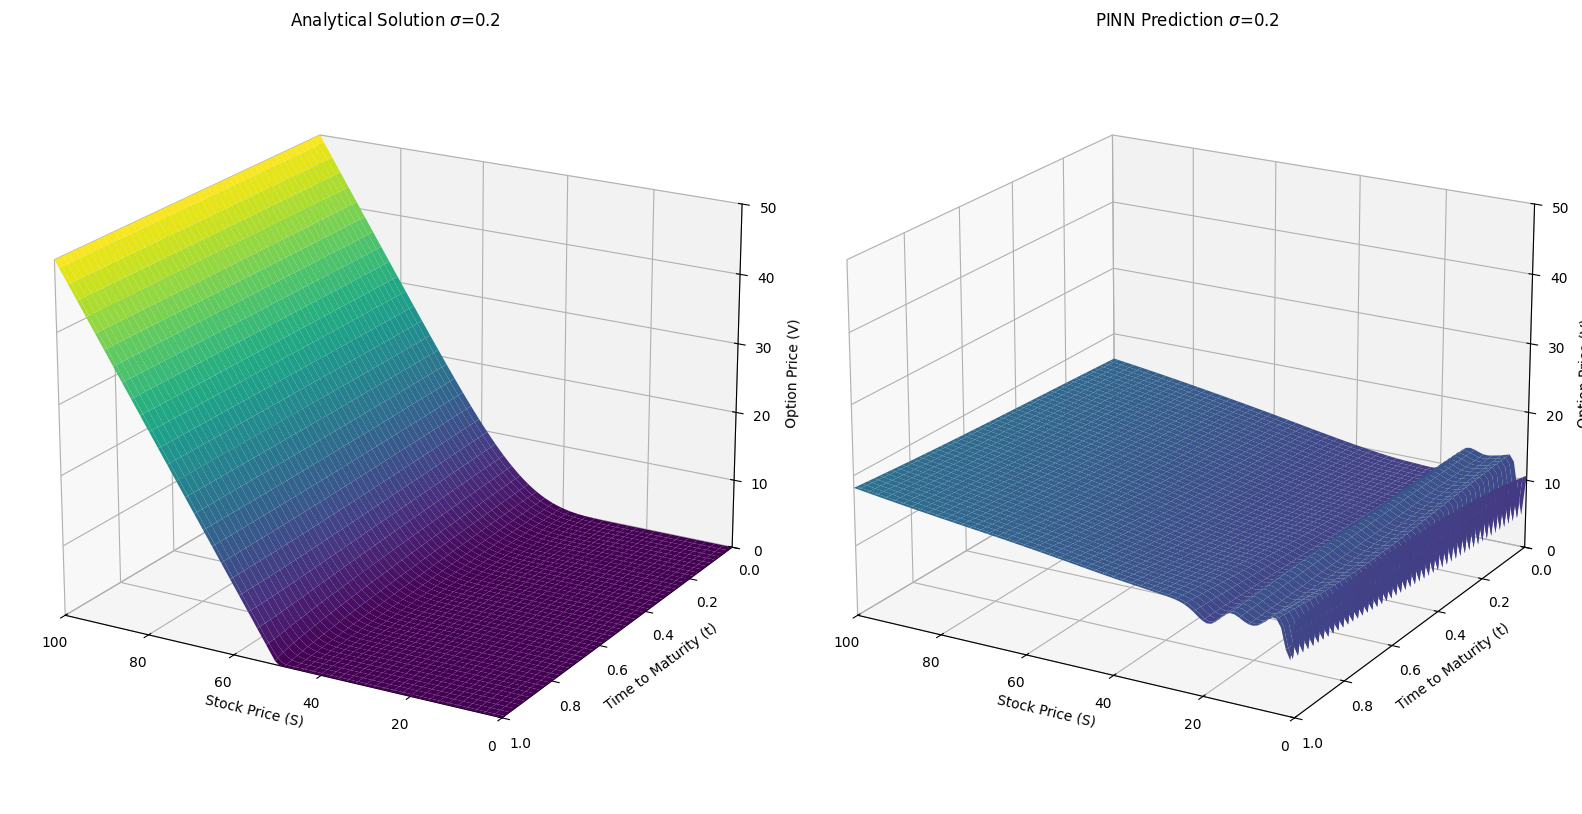

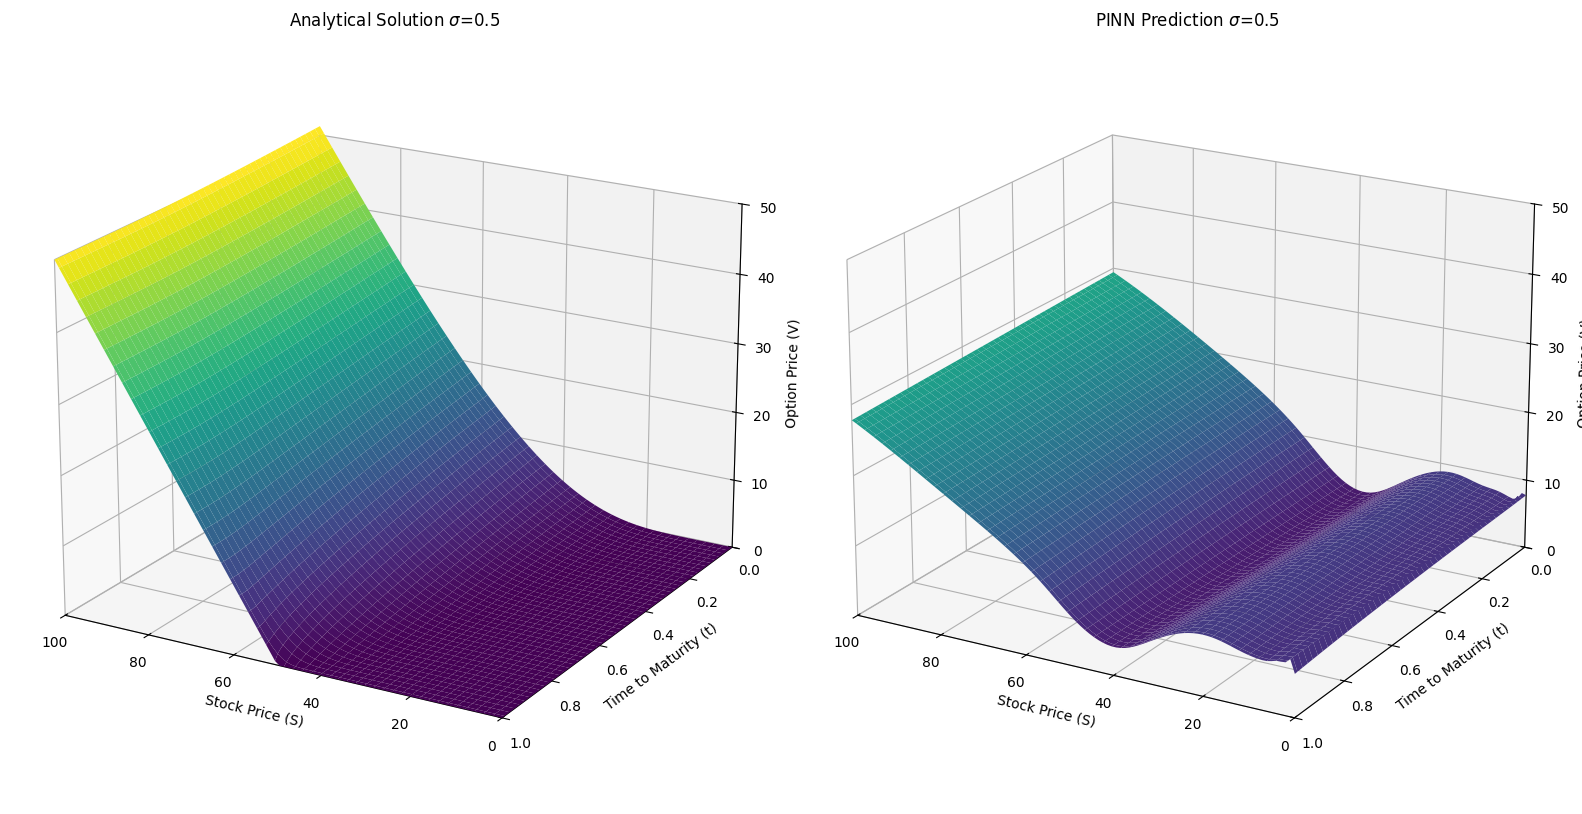

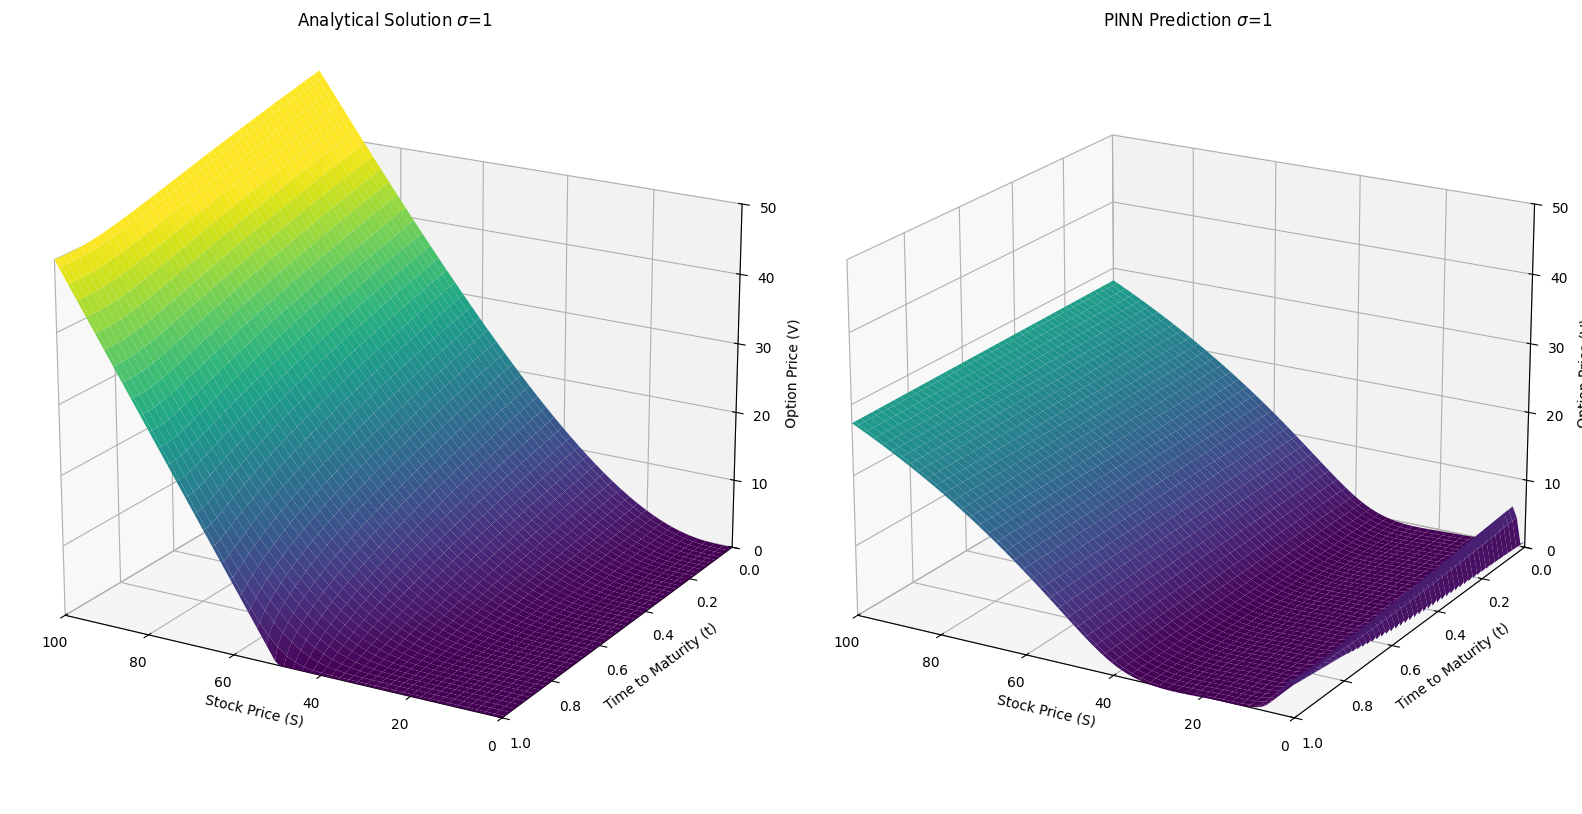

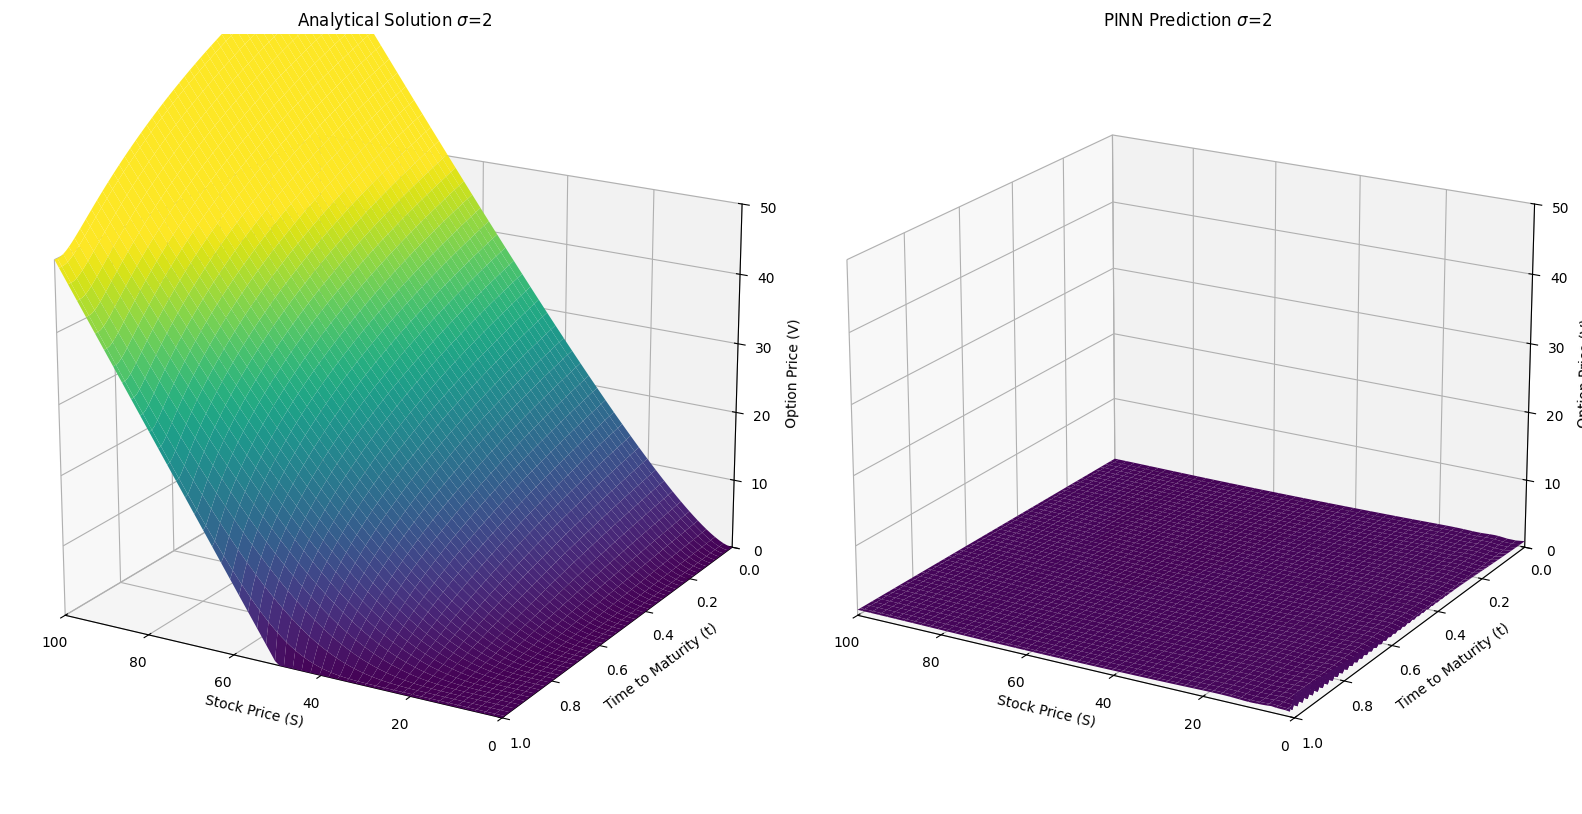

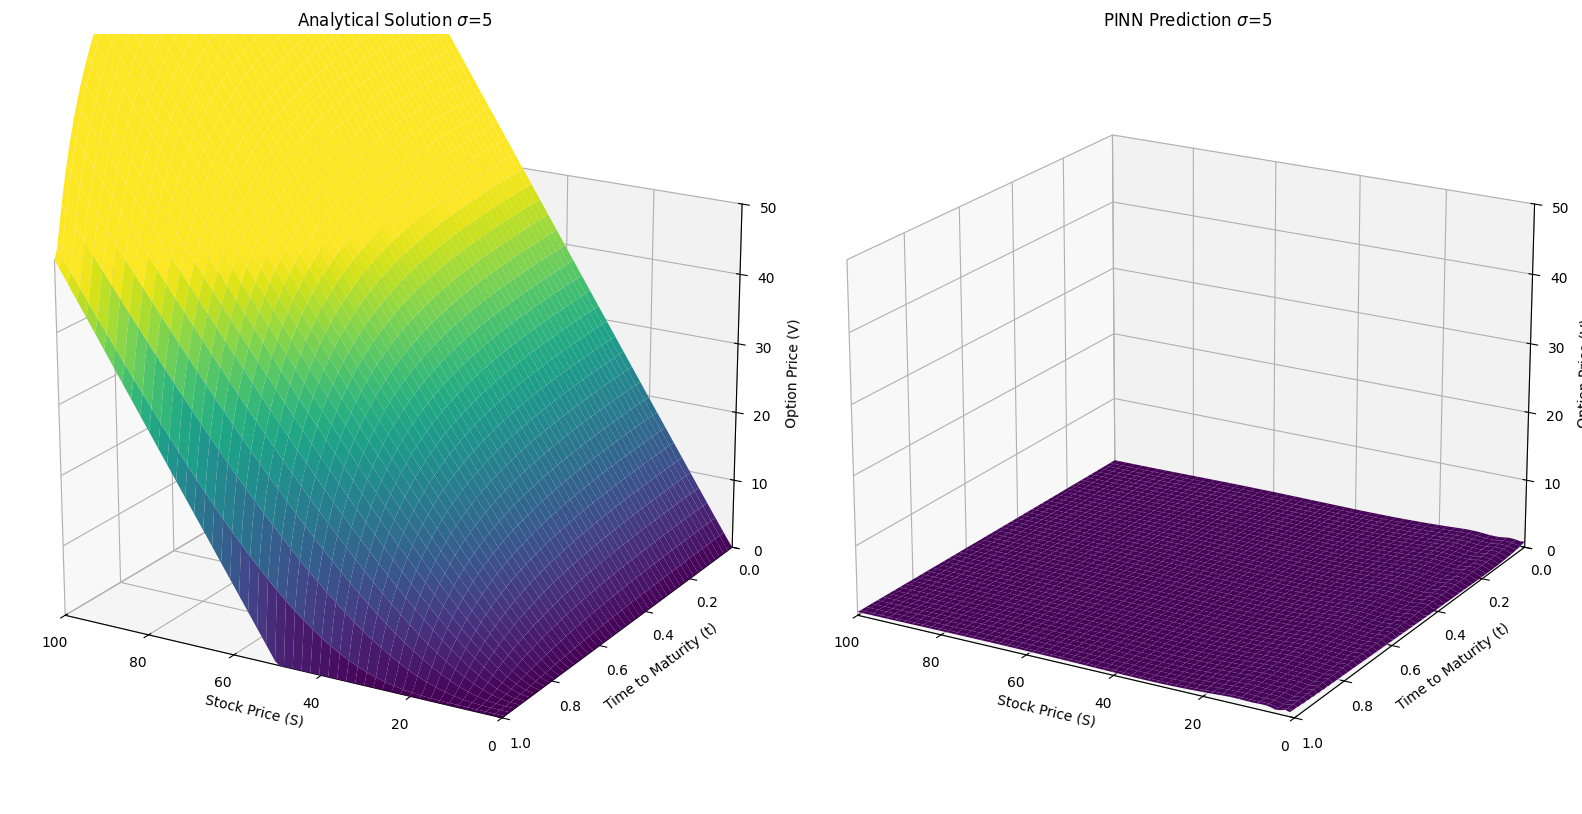

In [47]:
# Reuse the trained model to make predictions
def model_prediction(model, inputs):
    with torch.no_grad():
        return model(inputs)

S_range = torch.linspace(0, Smax, 100).view(-1, 1)  # Stock price
t_range = torch.linspace(0, T, 100).view(-1, 1)     # Time to maturity
S_grid, t_grid = torch.meshgrid(S_range.flatten(), t_range.flatten())
S_flat = S_grid.flatten().unsqueeze(1)
t_flat = t_grid.flatten().unsqueeze(1)
input_t = torch.cat((S_flat, t_flat), dim=1)

ana_sol = {}
preds_conven = {}

for sigma in sigma_values:

    analytical_values = black_scholes_analytical(input_t, K, T, sigma)
    analytical_values_plot = analytical_values.view(S_grid.shape).numpy()
    ana_sol[sigma] = analytical_values

    # Model predictions
    model_values = model_prediction(sig_models[sigma], input_t)
    model_values_plot = model_values.view(S_grid.shape).numpy()
    preds_conven[sigma] = model_values

    # Create 3D plots
    fig = plt.figure(figsize=(16, 8))

    # Analytical solution
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.plot_surface(S_grid.numpy(), t_grid.numpy(), analytical_values_plot, cmap='viridis', vmin=0, vmax=50, edgecolor='none')
    ax1.set_title(f"Analytical Solution $\sigma$={sigma}")
    ax1.set_xlabel("Stock Price (S)")
    ax1.set_ylabel("Time to Maturity (t)")
    ax1.set_zlabel("Option Price (V)")
    ax1.view_init(elev=20, azim=120)
    ax1.axis(xmin=0,xmax=Smax,ymin=0,ymax=T,zmin=0,zmax=50)

    # Model predictions
    ax2 = fig.add_subplot(122, projection='3d')
    ax2.plot_surface(S_grid.numpy(), t_grid.numpy(), model_values_plot, cmap='viridis', vmin=0, vmax=50, edgecolor='none')
    ax2.set_title(f"PINN Prediction $\sigma$={sigma}")
    ax2.set_xlabel("Stock Price (S)")
    ax2.set_ylabel("Time to Maturity (t)")
    ax2.set_zlabel("Option Price (V)")
    ax2.view_init(elev=20, azim=120)
    ax2.axis(xmin=0,xmax=Smax,ymin=0,ymax=T,zmin=0,zmax=50)

    plt.tight_layout()
    plt.show()

In [49]:
def relative_l2_loss(analytical, predicted):
    return np.linalg.norm(analytical - predicted) / np.linalg.norm(analytical)

In [50]:
L2_df = pd.DataFrame()
L2_df['sigma'] = sigma_values

L2_df['conventional'] = [relative_l2_loss(ana_sol[sigma], preds_conven[sigma]) for sigma in L2_df['sigma']]

display(L2_df)

,sigma,conventional
0,0.2,78.975235
1,0.5,83.183205
2,1.0,85.677567
3,2.0,98.368011
4,5.0,99.030357
